In [ ]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
Found existing installation: opencv-contrib-python 4.10.0.84
Uninstalling opencv-contrib-python-4.10.0.84:
  Successfully uninstalled opencv-contrib-python-4.10.0.84


In [ ]:
!pip install -q opencv-contrib-python==4.10.0.84

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import cv2

print("OpenCV Version:", cv2.__version__)
print("HOG Available:", hasattr(cv2, "HOGDescriptor"))

OpenCV Version: 4.10.0
HOG Available: True


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV Version:", cv2.__version__)

OpenCV Version: 4.10.0


In [ ]:
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

print("HOG + SVM Detector Initialized Successfully")

HOG + SVM Detector Initialized Successfully


In [ ]:
np.random.seed(42)

def create_street_scene(width=600, height=400, pedestrians=5):

    img = np.full((height, width, 3), 220, dtype=np.uint8)

    # Road
    cv2.rectangle(img, (0, height//2), (width, height), (70,70,70), -1)

    # Lane markings
    for x in range(30, width, 90):
        cv2.rectangle(img, (x, height-35), (x+40, height-25), (255,255,255), -1)

    actual_boxes = []

    for i in range(pedestrians):

        body_w = np.random.randint(30,45)
        body_h = np.random.randint(70,100)

        x = np.random.randint(20, width-body_w-20)
        y = np.random.randint(height//2-body_h//2, height-body_h-20)

        # Head
        cv2.circle(img, (x+body_w//2, y+12), 10, (0,0,0), -1)

        # Body
        cv2.rectangle(img, (x+8, y+22), (x+body_w-8, y+body_h-15), (0,0,0), -1)

        # Legs
        cv2.line(img, (x+12, y+body_h-15), (x+6, y+body_h), (0,0,0), 3)
        cv2.line(img, (x+body_w-12, y+body_h-15), (x+body_w-6, y+body_h), (0,0,0), 3)

        actual_boxes.append((x, y, body_w, body_h))

    return img, actual_boxes

street_image, actual_boxes = create_street_scene()

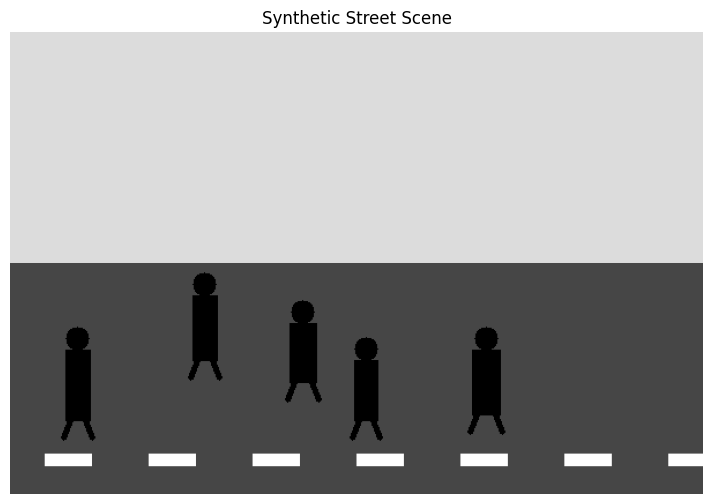

In [ ]:
plt.figure(figsize=(9,6))
plt.imshow(cv2.cvtColor(street_image, cv2.COLOR_BGR2RGB))
plt.title("Synthetic Street Scene")
plt.axis("off")
plt.show()

In [ ]:
boxes, weights = hog.detectMultiScale(
    street_image,
    winStride=(4,4),
    padding=(8,8),
    scale=1.05
)

print("Number of Pedestrians Detected:", len(boxes))

Number of Pedestrians Detected: 2


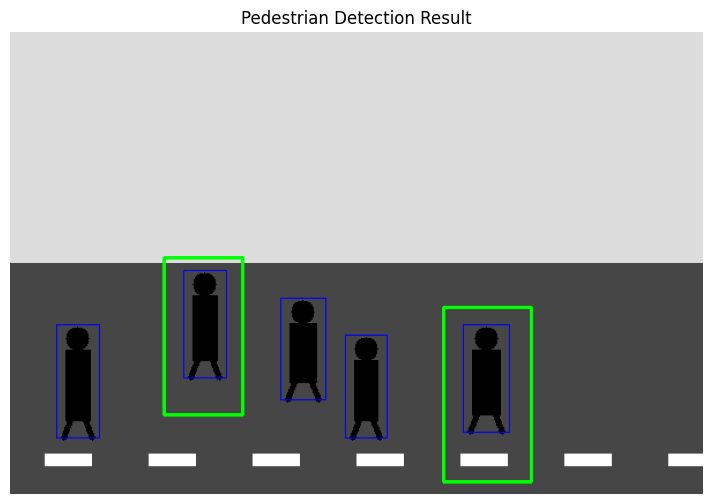

In [ ]:
detected_image = street_image.copy()

# Green = Detected pedestrians
for (x, y, w, h) in boxes:
    cv2.rectangle(detected_image, (x, y), (x+w, y+h), (0,255,0), 2)

# Blue = Original pedestrian positions
for (x, y, w, h) in actual_boxes:
    cv2.rectangle(detected_image, (x, y), (x+w, y+h), (255,0,0), 1)

plt.figure(figsize=(9,6))
plt.imshow(cv2.cvtColor(detected_image, cv2.COLOR_BGR2RGB))
plt.title("Pedestrian Detection Result")
plt.axis("off")
plt.show()

In [ ]:
print("Detected Pedestrian Coordinates\n")

for i, (x, y, w, h) in enumerate(boxes, start=1):
    print(f"Pedestrian {i}")
    print("X Coordinate :", x)
    print("Y Coordinate :", y)
    print("Width        :", w)
    print("Height       :", h)
    print("-" * 30)

Detected Pedestrian Coordinates

Pedestrian 1
X Coordinate : 375
Y Coordinate : 238
Width        : 76
Height       : 151
------------------------------
Pedestrian 2
X Coordinate : 133
Y Coordinate : 195
Width        : 68
Height       : 136
------------------------------


In [ ]:
print("Detection Confidence Scores\n")

if len(weights) == 0:
    print("No pedestrians detected.")
else:
    for i, score in enumerate(weights, start=1):
        print(f"Pedestrian {i} : {float(score):.3f}")

Detection Confidence Scores

Pedestrian 1 : 0.456
Pedestrian 2 : 1.322


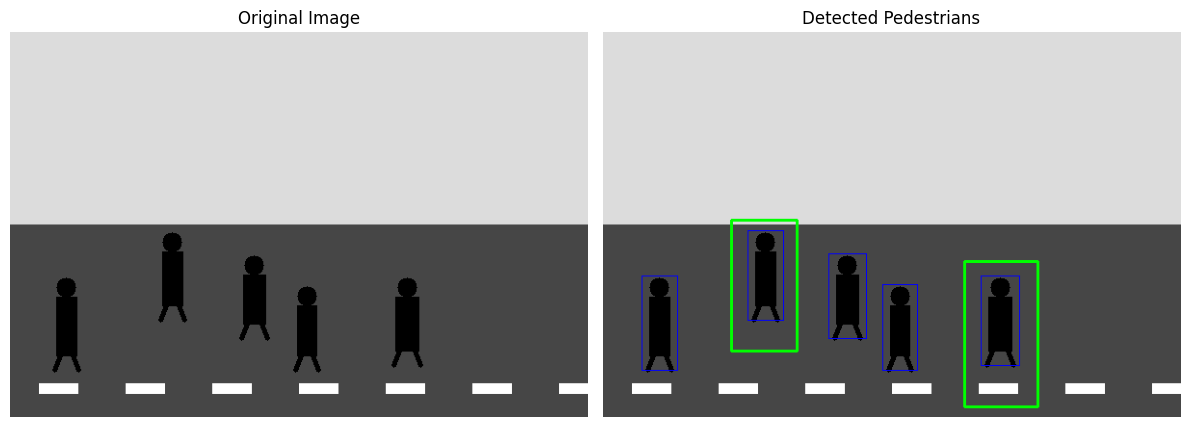

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(street_image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(detected_image, cv2.COLOR_BGR2RGB))
plt.title("Detected Pedestrians")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Pedestrian Detection using OpenCV completed successfully.")
print("Total Pedestrians Detected:", len(boxes))

Pedestrian Detection using OpenCV completed successfully.
Total Pedestrians Detected: 2
